### 1. Import packages

In [1]:
import os, sys, time, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import (
    ZooAttack, HopSkipJump,
    FastGradientMethod, ProjectedGradientDescentPyTorch,
    DeepFool, CarliniL2Method, SaliencyMapMethod,
)

### 2. Model architecture & Scaled wrapper

In [2]:
class _AttnPool(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.proj = nn.Linear(d, 1)
    def forward(self, H):
        w = torch.softmax(self.proj(H).squeeze(-1), dim=1)
        return (H * w.unsqueeze(-1)).sum(1)

class _LSTMTabular(nn.Module):
    def __init__(self, step_dim, hidden=256, layers=2, n_classes=12, dropout=0.15, bidir=True):
        super().__init__()
        self.step_dim = step_dim
        self.in_norm = nn.LayerNorm(step_dim)
        self.lstm = nn.LSTM(
            input_size=step_dim, hidden_size=hidden, num_layers=layers,
            batch_first=True, dropout=dropout if layers > 1 else 0.0, bidirectional=bidir,
        )
        d_out = hidden * (2 if bidir else 1)
        self.pool = _AttnPool(d_out)
        self.head = nn.Sequential(
            nn.Linear(d_out, d_out // 2), nn.ReLU(), nn.Dropout(0.20),
            nn.Linear(d_out // 2, n_classes),
        )
    def forward(self, x):
        B, F = x.shape
        S = int(math.ceil(F / self.step_dim))
        pad = S * self.step_dim - F
        if pad > 0:
            x = nn.functional.pad(x, (0, pad))
        x = self.in_norm(x.view(B, S, self.step_dim))
        H, _ = self.lstm(x)
        return self.head(self.pool(H))

class _ScaledLSTM(nn.Module):
    """Wraps _LSTMTabular with embedded StandardScaler so ART operates in raw feature space."""
    def __init__(self, lstm, mean, scale):
        super().__init__()
        self.lstm = lstm
        self.register_buffer('mean_', torch.tensor(mean, dtype=torch.float32))
        self.register_buffer('scale_', torch.tensor(scale, dtype=torch.float32))
    def forward(self, x):
        x = x.to(torch.float32)
        x_scaled = (x - self.mean_) / self.scale_
        return self.lstm(x_scaled)

### 3. Load data and trained model

In [3]:
# Load test data
df_test = pd.read_csv('../../datasets/test_shap_66.csv')
X_test = df_test.drop(columns=['Label']).values.astype(np.float32)
y_test = df_test['Label'].values.astype(int)
feature_names = df_test.columns[:-1].tolist()

print(f'Test set: {X_test.shape}, Classes: {len(np.unique(y_test))}')

Test set: (2028, 66), Classes: 12


In [4]:
# Load LSTM checkpoint
DEVICE = 'cpu'  # change to 'cuda' if GPU available
ckpt = torch.load('../../training/models/framework_lstm_TVAE.pth', map_location=DEVICE, weights_only=False)

lstm_net = _LSTMTabular(
    step_dim=int(ckpt['step_dim']),
    hidden=int(ckpt['hidden']),
    layers=int(ckpt['layers']),
    n_classes=int(ckpt['num_classes']),
    dropout=float(ckpt['dropout']),
    bidir=bool(ckpt['bidir']),
)
lstm_net.load_state_dict(ckpt['state_dict'])
lstm_net.eval()

scaled_model = _ScaledLSTM(lstm_net, ckpt['scaler'].mean_, ckpt['scaler'].scale_).to(DEVICE)
scaled_model.eval()

num_classes = int(ckpt['num_classes'])
input_dim = int(ckpt['scaler'].mean_.shape[0])

print(f'LSTM loaded: input_dim={input_dim}, classes={num_classes}')

LSTM loaded: input_dim=66, classes=12


### 4. Create ART classifier

Original Accuracy: 68.10%
Original Precision: 67.15%
Original Recall: 68.10%
Original F1 Score: 0.6675


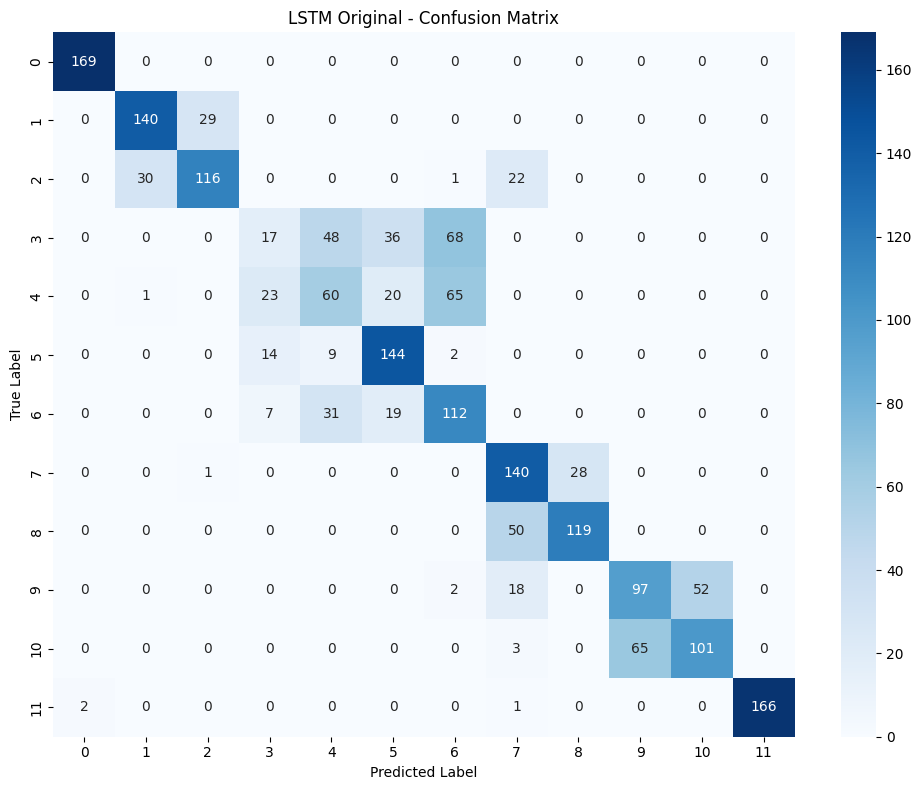

In [5]:
classifier = PyTorchClassifier(
    model=scaled_model,
    loss=nn.CrossEntropyLoss(),
    input_shape=(input_dim,),
    nb_classes=num_classes,
    clip_values=(float(X_test.min()), float(X_test.max())),
    device_type=DEVICE,
)

predictions = classifier.predict(X_test)
original_preds = np.argmax(predictions, axis=1)

original_accuracy = accuracy_score(y_test, original_preds) * 100
original_f1 = f1_score(y_test, original_preds, average='weighted')
original_precision = precision_score(y_test, original_preds, average='weighted') * 100
original_recall = recall_score(y_test, original_preds, average='weighted') * 100

print(f'Original Accuracy: {original_accuracy:.2f}%')
print(f'Original Precision: {original_precision:.2f}%')
print(f'Original Recall: {original_recall:.2f}%')
print(f'Original F1 Score: {original_f1:.4f}')

cm = confusion_matrix(y_test, original_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('LSTM Original - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [6]:
def evaluate_attack(y_test, y_pred, attack_name):
    predictions = np.argmax(y_pred, axis=1)
    accuracy = accuracy_score(y_test, predictions) * 100
    f1 = f1_score(y_test, predictions, average='macro')
    precision = precision_score(y_test, predictions, average='macro') * 100
    recall = recall_score(y_test, predictions, average='macro') * 100

    print(f'--- {attack_name} ---')
    print(f'Accuracy on {attack_name} adversarial examples: {accuracy:.2f}%')
    print(f'Precision on {attack_name} adversarial examples: {precision:.2f}%')
    print(f'Recall on {attack_name} adversarial examples: {recall:.2f}%')
    print(f'F1 Score on {attack_name} adversarial examples: {f1:.4f}')

    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'LSTM {attack_name} - Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

def save_adv_csv(adv_samples, y, feature_names, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    df = pd.DataFrame(adv_samples, columns=feature_names)
    df['Label'] = y
    df.to_csv(path, index=False)
    print(f'Saved: {path}')

### 5. Generate adversarial samples

DL models support all 7 attacks: FGSM, PGD, DeepFool, CW, JSMA (white-box) + ZOO, HSJA (black-box)

#### FGSM

Runtime: 0.95s
--- FGSM ---
Accuracy on FGSM adversarial examples: 40.19%
Precision on FGSM adversarial examples: 43.81%
Recall on FGSM adversarial examples: 40.19%
F1 Score on FGSM adversarial examples: 0.3839


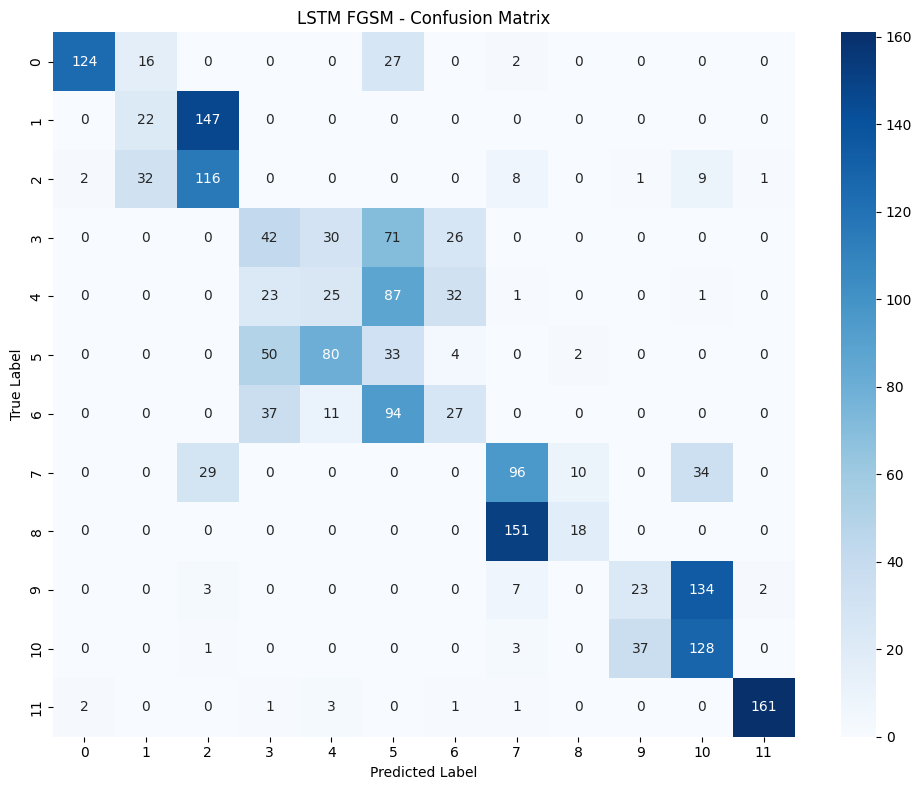

Saved: ../../adv_samples/adv_eval/lstm/lstm_fgsm_adv.csv


In [7]:
attack = FastGradientMethod(
    estimator=classifier,
    eps=0.1,
    eps_step=0.01,
    batch_size=64,
    targeted=False,
)

start_time = time.time()
FGSM_adv_samples = attack.generate(x=X_test)
print(f'Runtime: {time.time() - start_time:.2f}s')

predictions_adv = classifier.predict(FGSM_adv_samples)
evaluate_attack(y_test, predictions_adv, 'FGSM')
save_adv_csv(FGSM_adv_samples, y_test, feature_names, '../../adv_samples/adv_eval/lstm/lstm_fgsm_adv.csv')

#### PGD

Runtime: 145.17s
--- PGD ---
Accuracy on PGD adversarial examples: 22.93%
Precision on PGD adversarial examples: 26.71%
Recall on PGD adversarial examples: 22.93%
F1 Score on PGD adversarial examples: 0.2232


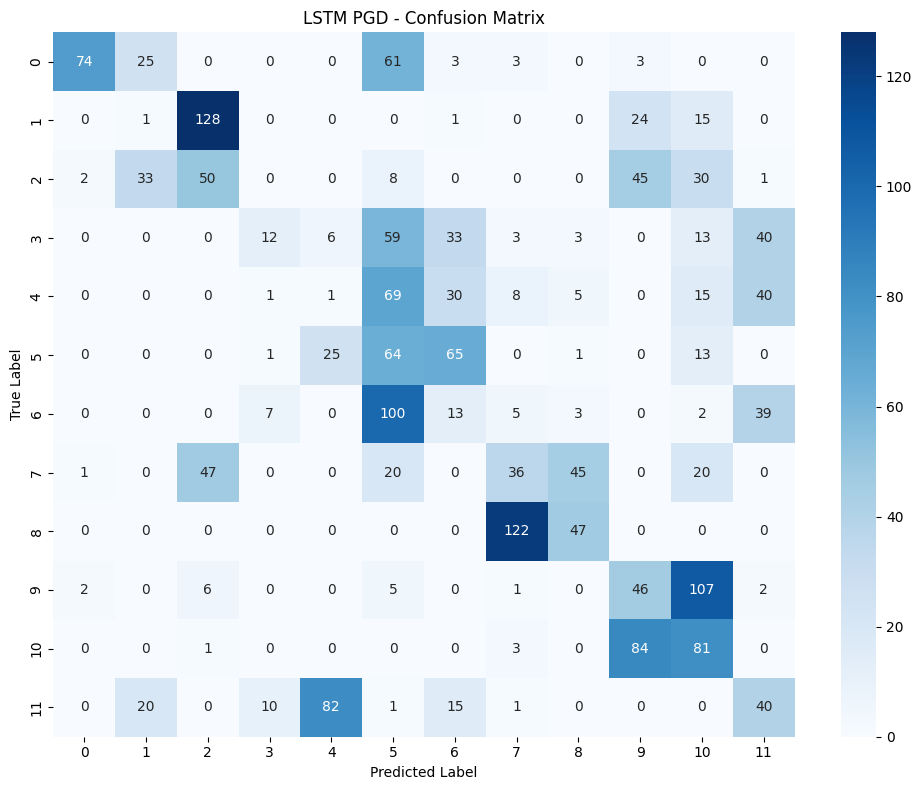

Saved: ../../adv_samples/adv_eval/lstm/lstm_pgd_adv.csv


In [8]:
attack = ProjectedGradientDescentPyTorch(
    estimator=classifier,
    eps=0.2,
    eps_step=0.01,
    max_iter=200,
    batch_size=64,
    targeted=False,
    verbose=True,
)

start_time = time.time()
PGD_adv_samples = attack.generate(x=X_test)
print(f'Runtime: {time.time() - start_time:.2f}s')

predictions_adv = classifier.predict(PGD_adv_samples)
evaluate_attack(y_test, predictions_adv, 'PGD')
save_adv_csv(PGD_adv_samples, y_test, feature_names, '../../adv_samples/adv_eval/lstm/lstm_pgd_adv.csv')

#### DeepFool

DeepFool: 100%|██████████| 32/32 [00:21<00:00,  1.47it/s]


Runtime: 22.21s
--- DeepFool ---
Accuracy on DeepFool adversarial examples: 12.48%
Precision on DeepFool adversarial examples: 12.87%
Recall on DeepFool adversarial examples: 12.48%
F1 Score on DeepFool adversarial examples: 0.1179


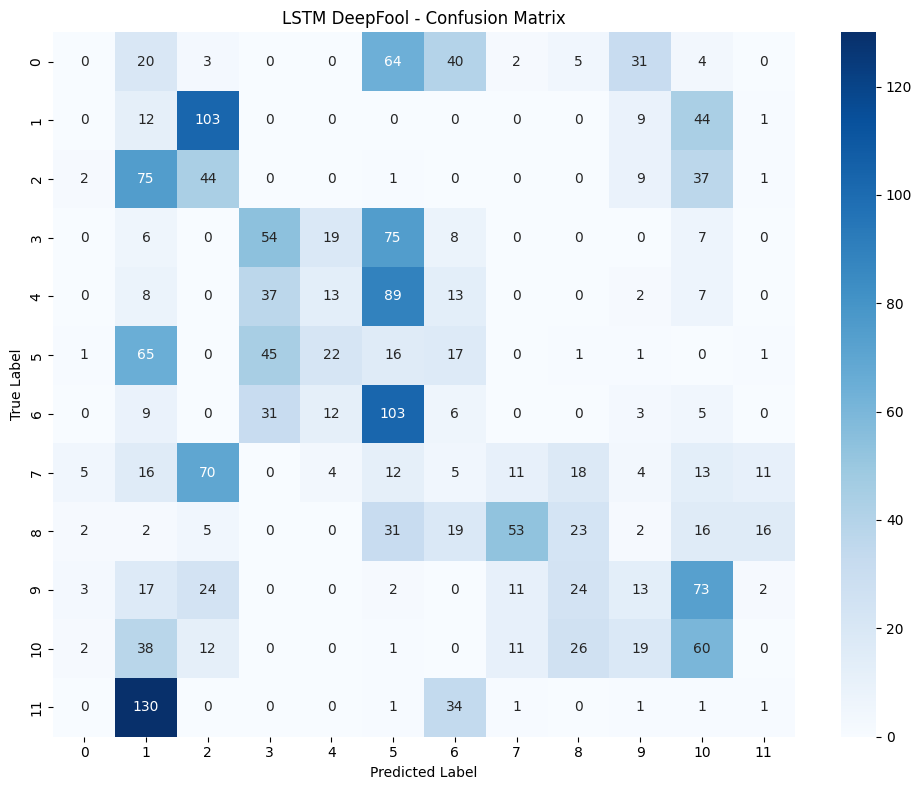

Saved: ../../adv_samples/adv_eval/lstm/lstm_deepfool_adv.csv


In [9]:
attack = DeepFool(
    classifier=classifier,
    max_iter=100,
    batch_size=64,
    nb_grads=5,
    epsilon=1e-6,
)

start_time = time.time()
DeepFool_adv_samples = attack.generate(x=X_test)
print(f'Runtime: {time.time() - start_time:.2f}s')

predictions_adv = classifier.predict(DeepFool_adv_samples)
evaluate_attack(y_test, predictions_adv, 'DeepFool')
save_adv_csv(DeepFool_adv_samples, y_test, feature_names, '../../adv_samples/adv_eval/lstm/lstm_deepfool_adv.csv')

#### C&W

Runtime: 45.22s
--- C&W ---
Accuracy on C&W adversarial examples: 42.55%
Precision on C&W adversarial examples: 44.21%
Recall on C&W adversarial examples: 42.55%
F1 Score on C&W adversarial examples: 0.3886


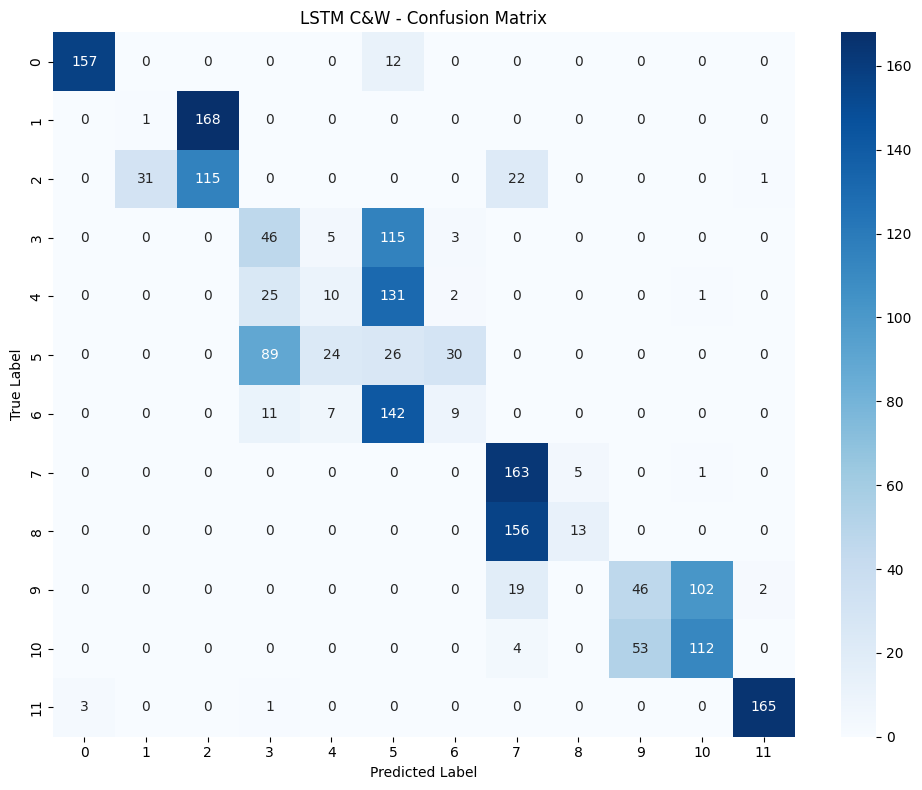

Saved: ../../adv_samples/adv_eval/lstm/lstm_cw_adv.csv


In [10]:
attack = CarliniL2Method(
    classifier=classifier,
    confidence=0.0,
    learning_rate=0.01,
    binary_search_steps=3,
    max_iter=3,
    initial_const=0.01,
    max_halving=5,
    max_doubling=5,
    batch_size=64,
    verbose=False,
)

start_time = time.time()
CW_adv_samples = attack.generate(x=X_test)
print(f'Runtime: {time.time() - start_time:.2f}s')

predictions_adv = classifier.predict(CW_adv_samples)
evaluate_attack(y_test, predictions_adv, 'C&W')
save_adv_csv(CW_adv_samples, y_test, feature_names, '../../adv_samples/adv_eval/lstm/lstm_cw_adv.csv')

#### JSMA

JSMA: 100%|██████████| 32/32 [05:24<00:00, 10.13s/it]


Runtime: 324.63s
--- JSMA ---
Accuracy on JSMA adversarial examples: 13.56%
Precision on JSMA adversarial examples: 20.02%
Recall on JSMA adversarial examples: 13.56%
F1 Score on JSMA adversarial examples: 0.1123


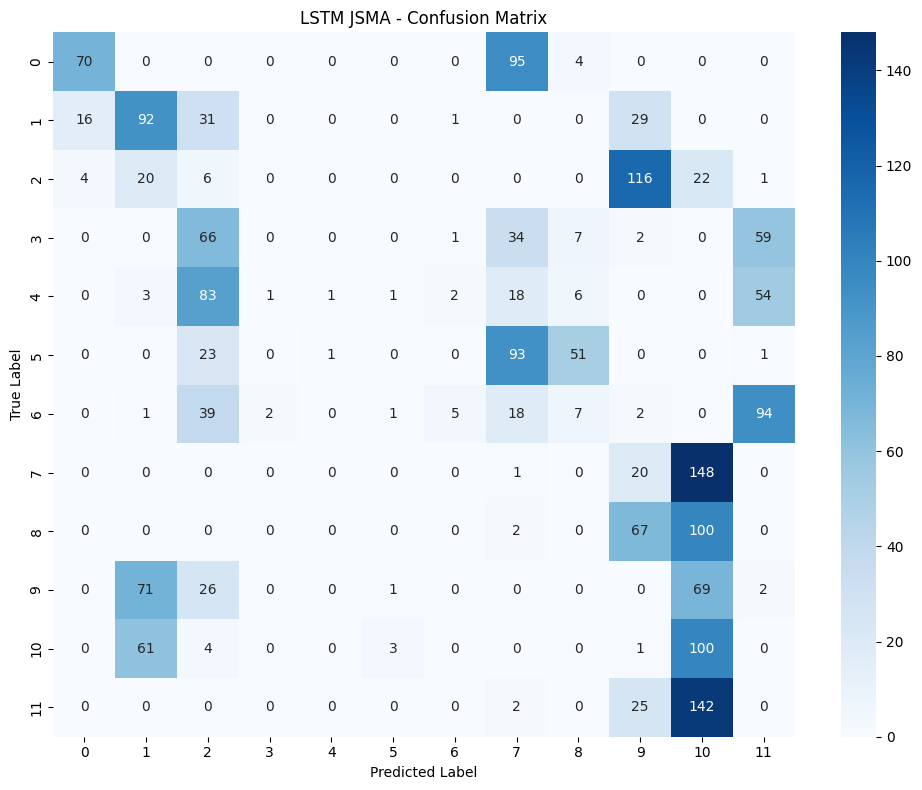

Saved: ../../adv_samples/adv_eval/lstm/lstm_jsma_adv.csv


In [14]:
attack = SaliencyMapMethod(
    classifier=classifier,
    theta=0.02,
    gamma=0.1,
    batch_size=64,
    verbose=True,
)

start_time = time.time()
JSMA_adv_samples = attack.generate(x=X_test)
print(f'Runtime: {time.time() - start_time:.2f}s')

predictions_adv = classifier.predict(JSMA_adv_samples)
evaluate_attack(y_test, predictions_adv, 'JSMA')
save_adv_csv(JSMA_adv_samples, y_test, feature_names, '../../adv_samples/adv_eval/lstm/lstm_jsma_adv.csv')

#### ZOO

ZOO: 100%|██████████| 2028/2028 [25:38<00:00,  1.32it/s]


Runtime: 1544.80s
--- ZOO ---
Accuracy on ZOO adversarial examples: 25.89%
Precision on ZOO adversarial examples: 33.32%
Recall on ZOO adversarial examples: 25.89%
F1 Score on ZOO adversarial examples: 0.2603


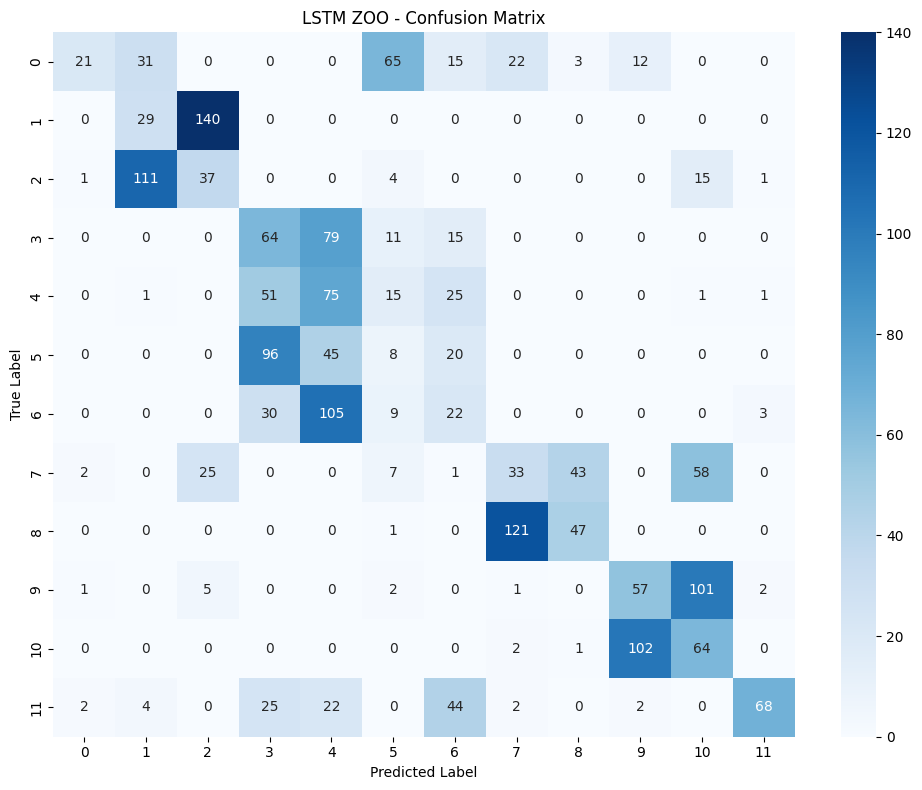

Saved: ../../adv_samples/adv_eval/lstm/lstm_zoo_adv.csv


In [ ]:
attack = ZooAttack(
    classifier=classifier,
    confidence=0.0,
    targeted=False,
    learning_rate=1e-1,
    max_iter=100,
    binary_search_steps=3,
    initial_const=1e-3,
    abort_early=True,
    use_resize=False,
    use_importance=False,
    nb_parallel=10,
    batch_size=1,
    variable_h=0.02,
)

start_time = time.time()
ZOO_adv_samples = attack.generate(x=X_test)
print(f'Runtime: {time.time() - start_time:.2f}s')

predictions_adv = classifier.predict(ZOO_adv_samples)
evaluate_attack(y_test, predictions_adv, 'ZOO')
save_adv_csv(ZOO_adv_samples, y_test, feature_names, '../../adv_samples/adv_eval/lstm/lstm_zoo_adv.csv')

#### HSJA

HopSkipJump: 100%|██████████| 2028/2028 [04:02<00:00,  8.36it/s]


Runtime: 243.91
--- HSJA ---
Accuracy on HSJA adversarial examples: 10.26%
Precision on HSJA adversarial examples: 13.31%
Recall on HSJA adversarial examples: 10.26%
F1 Score on HSJA adversarial examples: 0.0952


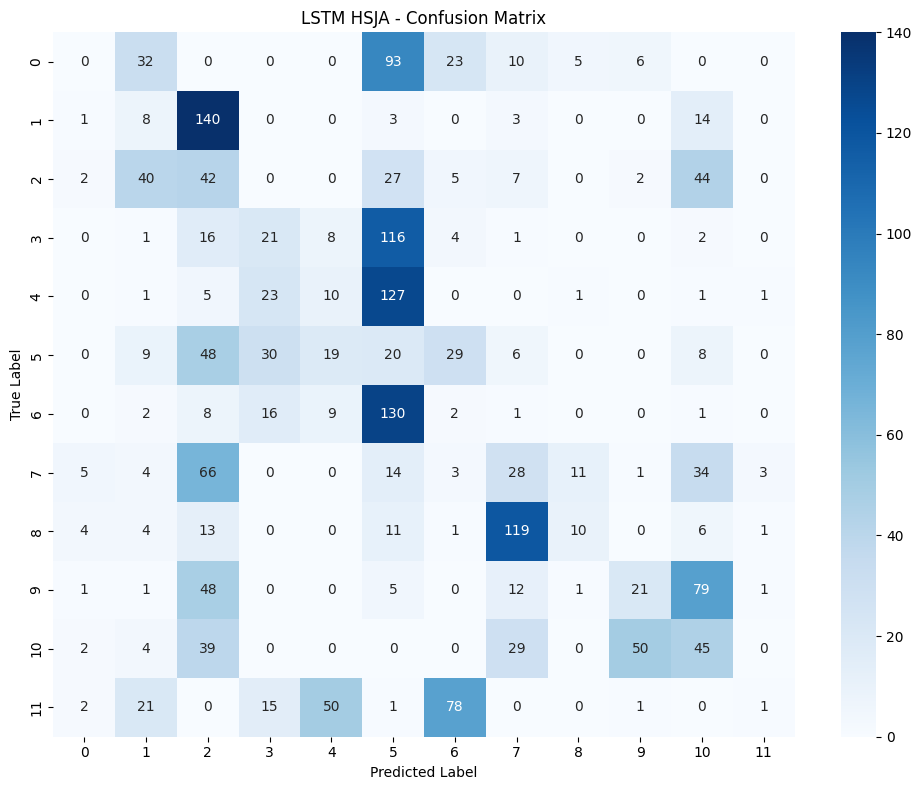

Saved: ../../adv_samples/adv_eval/lstm/lstm_hsja_adv.csv


In [12]:
attack = HopSkipJump(
    classifier=classifier,
    batch_size=64,
    targeted=False,
    norm=2,
    max_iter=5,
    max_eval=100,
    init_eval=10,
    init_size=10,
    verbose=True,
)

start_time = time.time()
HSJA_adv_samples = attack.generate(x=X_test)
print(f'Runtime: {time.time() - start_time:.2f}')


predictions_adv = classifier.predict(HSJA_adv_samples)
evaluate_attack(y_test, predictions_adv, 'HSJA')
save_adv_csv(HSJA_adv_samples, y_test, feature_names, '../../adv_samples/adv_eval/lstm/lstm_hsja_adv.csv')

### 6. ASR (Attack Success Rate)

In [27]:

y_pred_org = original_preds
correct_indices = np.where(y_test == y_pred_org)[0]


adv_dir = '../../adv_samples/adv_eval/lstm'
attack_names = ['fgsm', 'pgd', 'deepfool', 'cw', 'jsma', 'zoo', 'hsja']
attack_samples = {}

for atk in attack_names:
    path = os.path.join(adv_dir, f'lstm_{atk}_adv.csv')
    if os.path.exists(path):
        df = pd.read_csv(path)
        attack_samples[atk.upper()] = df.drop(columns=['Label']).values.astype(np.float32)

print('=== LSTM Attack Success Rate ===')
for name, adv in attack_samples.items():
    preds_adv = np.argmax(classifier.predict(adv), axis=1)
    asr = np.sum(y_pred_org[correct_indices] != preds_adv[correct_indices]) / len(correct_indices) * 100
    print(f'{name:>10s} ASR: {asr:.2f}%')

=== LSTM Attack Success Rate ===
      FGSM ASR: 59.67%
       PGD ASR: 84.94%
  DEEPFOOL ASR: 100.00%
        CW ASR: 52.35%
      JSMA ASR: 80.74%
       ZOO ASR: 92.11%
      HSJA ASR: 100.00%
